## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [2]:
EXPERIMENT_NAME='TL/04_efficientnetv2_without_tl'
assert(not EXPERIMENT_NAME is None)

import tensorflow as tf
import uuid
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import warnings
import rasterio
import json
import glob
import shutil

# Reduce TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Activation, Rescaling
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import TerminateOnNaN, ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix

%matplotlib inline
print(tf.config.list_physical_devices('GPU'))

2026-01-09 14:51:24.272626: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 14:51:24.280258: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-09 14:51:24.289503: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-09 14:51:24.292564: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-09 14:51:24.299690: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1767970285.694914  325083 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767970285.726262  325083 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767970285.728064  325083 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [3]:
PROJECT_PATH = "/workspace/COMPUTERVISIONPROYECT"
DATASET_NAME = 'stratified'

XVIEW_RECOGNITION_PATH = os.path.join(PROJECT_PATH, "data/xview_recognition")

EXPERIMENT_PATH = os.path.join(PROJECT_PATH, "experiment_results", EXPERIMENT_NAME)
EXPERIMENT_RESULTS = os.path.join(EXPERIMENT_PATH, "results")
assert(not os.path.exists(EXPERIMENT_PATH))
if not os.path.exists(EXPERIMENT_PATH):
    os.mkdir(EXPERIMENT_PATH)
    os.mkdir(EXPERIMENT_RESULTS)
CHECKPOINT_DIR = os.path.join(EXPERIMENT_PATH, 'model_checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_WEIGHTS_FILENAME_PATTERN = os.path.join(CHECKPOINT_DIR, 'epoch_{epoch:03d}-val_loss_{val_loss:.4f}.keras')
MODEL_PATH = os.path.join(EXPERIMENT_PATH, 'model.keras')

CM_PATH = os.path.join(EXPERIMENT_RESULTS, 'cm.png')
METRICS_PATH = os.path.join(EXPERIMENT_RESULTS, 'metrics.csv')
ACC_LOSS_PATH = os.path.join(EXPERIMENT_RESULTS, 'acc_loss.png')
TEST_PREDICTS_PATH = os.path.join(EXPERIMENT_RESULTS, 'prediction.json')
HISTORY_PATH = os.path.join(EXPERIMENT_RESULTS, 'history.csv')

TRAIN_SET_FILENAME = '_'.join([DATASET_NAME, 'train.tfrecord'])
VALIDATION_SET_FILENAME = '_'.join([DATASET_NAME, 'validation.tfrecord'])
TRAIN_SET_PATH = os.path.join(XVIEW_RECOGNITION_PATH, TRAIN_SET_FILENAME)
VALIDATION_SET_PATH = os.path.join(XVIEW_RECOGNITION_PATH, VALIDATION_SET_FILENAME)

# Tensorboard
LOG_DIR = os.path.join(EXPERIMENT_PATH, 'logs')
os.makedirs(LOG_DIR, exist_ok=True)

SYMLINK_PATH = os.path.join('/workspace', 'tensorboard_logs')
if os.path.islink(SYMLINK_PATH):
    os.unlink(SYMLINK_PATH)
os.symlink(LOG_DIR, SYMLINK_PATH)

## Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = None
DROPOUT_RATE = 0.5
REGULARIZER_PENALTY = None
EPOCHS = 20

categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

# Required classes and functions

In [4]:
class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [5]:
def draw_confusion_matrix(cm, categories, save_path=None, exp_name=None):
    # Draw confusion matrix
    fig = plt.figure(figsize=[3.2*pow(len(categories), 0.5), 2.4*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(15-pow(len(categories), 0.5)))
    fig.tight_layout()

    if save_path:
        if exp_name:
            plt.title(exp_name)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Gráfico guardado en: {save_path}")

    plt.show()

# 0. La usamos para las imágenes de test
def load_geoimage(filename_tensor):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    filename = filename_tensor
    src_raster = rasterio.open(filename, 'r')

    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

# 1. Función para decodificar los ejemplos del archivo
def _parse_image_function(example_proto):
    feature_description = {
        'height': tf.io.FixedLenFeature([], tf.int64),
        'width': tf.io.FixedLenFeature([], tf.int64),
        'depth': tf.io.FixedLenFeature([], tf.int64),
        'category_id': tf.io.FixedLenFeature([], tf.int64),
        'image_raw': tf.io.FixedLenFeature([], tf.string),
    }
    
    features = tf.io.parse_single_example(example_proto, feature_description)
    
    image = tf.io.decode_raw(features['image_raw'], out_type=tf.uint8)
    shape = [features['height'], features['width'], features['depth']]
    image = tf.reshape(image, shape)
    image = tf.cast(image, tf.float32)
    
    image = tf.image.resize(image, [224, 224])
    
    category_id = tf.cast(features['category_id'], tf.int32)
    label = tf.one_hot(category_id, depth=len(categories))
    
    return image, label

# 2. Función para crear el dataset
def create_tfrecord_dataset(filenames, batch_size, do_shuffle=False):
    # Lee los archivos TFRecord. Puede leer de múltiples archivos en paralelo.
    dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads=tf.data.AUTOTUNE)
    
    dataset = dataset.map(_parse_image_function, num_parallel_calls=tf.data.AUTOTUNE)
    # dataset = dataset.cache()
    
    if do_shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

# Datasets definition

In [6]:
train_dataset = create_tfrecord_dataset([TRAIN_SET_PATH], BATCH_SIZE, do_shuffle=True)
valid_dataset = create_tfrecord_dataset([VALIDATION_SET_PATH], BATCH_SIZE)

I0000 00:00:1767970286.022963  325083 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767970286.025388  325083 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767970286.027208  325083 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1767970286.158759  325083 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [7]:
y_train_labels = []
for _,label_idxs in train_dataset:
    y_train_labels += list(label_idxs.numpy().argmax(axis=1))

index,freqs = np.unique(y_train_labels, return_counts=True)
categories_count = pd.Series(freqs, index=[categories[idx] for idx in index], name='Size').sort_values(ascending=False)

categories_count

2026-01-09 14:51:28.971646: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Building              3235
Small car             2992
Truck                 1989
Bus                   1591
Shipping container    1371
Storage tank          1322
Dump truck            1112
Motorboat              962
Excavator              710
Fishing vessel         635
Cargo plane            571
Pylon                  281
Helipad                100
Name: Size, dtype: int64

# Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [8]:
from tensorflow.keras.applications import EfficientNetV2B0

base_model = EfficientNetV2B0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = True


model = Sequential(name=EXPERIMENT_NAME)
model.add(base_model)
model.add(Flatten(name='Flatten'))

model.add(Dense(256, activation='relu'))
model.add(Dropout(DROPOUT_RATE))
model.add(Dense(len(categories), activation='softmax'))

model.summary()

Model: "TL/04_efficientnetv2_without_tl"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Functio  (None, 7, 7, 1280)        5919312   
 nal)                                                            
                                                                 
 Flatten (Flatten)           (None, 62720)             0         
                                                                 
 dense (Dense)               (None, 256)               16056576  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 13)                3341      
                                                                 
Total params: 21979229 (83.84 MB)
Trainable params: 21918621 (83.61 MB)
Non-trainable params: 60608 (

In [9]:
opt = Adam(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Callbacks
model_checkpoint = ModelCheckpoint(
    filepath=BEST_WEIGHTS_FILENAME_PATTERN,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True
)

tensorboard_callback = TensorBoard(
    log_dir=LOG_DIR,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq='epoch',
    profile_batch=0
)

reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.5, patience=5, verbose=1, min_lr=1e-6)
terminate = TerminateOnNaN()
early_stop = EarlyStopping('val_accuracy', patience=EPOCHS, verbose=1, restore_best_weights=False)
callbacks = [reduce_lr, early_stop, terminate, model_checkpoint, tensorboard_callback]

In [11]:
print('Training model')
h = model.fit(train_dataset, 
              validation_data=valid_dataset, 
              epochs=EPOCHS, 
              callbacks=callbacks, 
              verbose=1)

history_df = pd.DataFrame(model.history.history).reset_index(names=['epoch'])
history_df['checkpoint'] = False

checkpoints = glob.glob(os.path.join(CHECKPOINT_DIR, '*.keras'))

if checkpoints:
    # Copiamos el mejor modelo en la ruta {EXPERIMENT_PATH}/model.keras
    # Ordenar los archivos por el valor de 'val_loss' (que está en el nombre)
    # y coger el primero (el que tenga el valor más bajo)
    BEST_WEIGHTS_FILENAME = min(checkpoints, key=lambda x: float(x.split('val_loss_')[1].replace('.keras', '')))
    model.load_weights(BEST_WEIGHTS_FILENAME)
    model.save(MODEL_PATH)

    print(f"El mejor modelo se encuentra en: {MODEL_PATH}")
else:
    print("No se encontraron checkpoints.")

history_df.to_csv(HISTORY_PATH, index=False)
print(f"El historial se encuentra en: {HISTORY_PATH}")

Training model


'''+ptx85+ptx85+ptx85' is not a recognized feature for this target' is not a recognized feature for this target' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
 (ignoring feature)
'''+ptx85+ptx85' is not a recognized feature for this target+ptx85' is not a recognized feature for this target (ignoring feature)
' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/20


2026-01-09 14:51:41.490162: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1026] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inTL/04_efficientnetv2_without_tl/efficientnetv2-b0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for 

      1/Unknown - 26s 26s/step - loss: 3.3358 - accuracy: 0.0781

...


Epoch 3: val_loss improved from 1.67808 to 1.29634, saving model to /workspace/COMPUTERVISIONPROYECT/experiment_results/TL/04_efficientnetv2_without_tl/model_checkpoints/epoch_003-val_loss_1.2963.keras


W0000 00:00:1767970407.420649  325175 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970407.420907  325175 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970407.421047  325175 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970407.421234  325175 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970407.421378  325175 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970407.421594  325175 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970407.421868  325175 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970407.422126  325175 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970407.422491  325175 gp

264/264 [==============================] - 31s 116ms/step - loss: 1.5607 - accuracy: 0.4910 - val_loss: 1.2963 - val_accuracy: 0.5872 - lr: 0.0010
Epoch 4/20
264/264 [==============================] - ETA: 0s - loss: 1.4906 - accuracy: 0.5308

W0000 00:00:1767970437.324748  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970437.325086  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970437.325345  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970437.325598  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970437.326023  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970437.326296  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970437.326702  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970437.327016  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767970437.327420  325173 gp


Epoch 4: val_loss improved from 1.29634 to 1.24849, saving model to /workspace/COMPUTERVISIONPROYECT/experiment_results/TL/04_efficientnetv2_without_tl/model_checkpoints/epoch_004-val_loss_1.2485.keras
264/264 [==============================] - 31s 116ms/step - loss: 1.4906 - accuracy: 0.5308 - val_loss: 1.2485 - val_accuracy: 0.6075 - lr: 0.0010
Epoch 5/20
264/264 [==============================] - ETA: 0s - loss: 1.2684 - accuracy: 0.5925
Epoch 5: val_loss did not improve from 1.24849
264/264 [==============================] - 31s 117ms/step - loss: 1.2684 - accuracy: 0.5925 - val_loss: 1.3133 - val_accuracy: 0.6032 - lr: 0.0010
Epoch 6/20
264/264 [==============================] - ETA: 0s - loss: 1.1367 - accuracy: 0.6303
Epoch 6: val_loss improved from 1.24849 to 1.06784, saving model to /workspace/COMPUTERVISIONPROYECT/experiment_results/TL/04_efficientnetv2_without_tl/model_checkpoints/epoch_006-val_loss_1.0678.keras
264/264 [==============================] - 30s 115ms/step - lo

# Validation
Compute validation metrics.

In [12]:
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Model: "TL/04_efficientnetv2_without_tl"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Functio  (None, 7, 7, 1280)        5919312   
 nal)                                                            
                                                                 
 Flatten (Flatten)           (None, 62720)             0         
                                                                 
 dense (Dense)               (None, 256)               16056576  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 13)                3341      
                                                                 
Total params: 21979229 (83.84 MB)
Trainable params: 21918621 (83.61 MB)
Non-trainable params: 60608 (

In [13]:
predictions = model.predict(valid_dataset)
category_names = np.array(list(categories.values()))
y_pred = category_names[predictions.argmax(axis=1)]

y_true = []

for images_batch, labels_batch in valid_dataset:
    labels_np = labels_batch.numpy()
    
    true_indices = np.argmax(labels_np, axis=1)
    batch_labels = category_names[true_indices]
    
    y_true.extend(batch_labels)

30/30 [==============================] - 2s 24ms/step


Gráfico guardado en: /workspace/COMPUTERVISIONPROYECT/experiment_results/TL/04_efficientnetv2_without_tl/results/cm.png


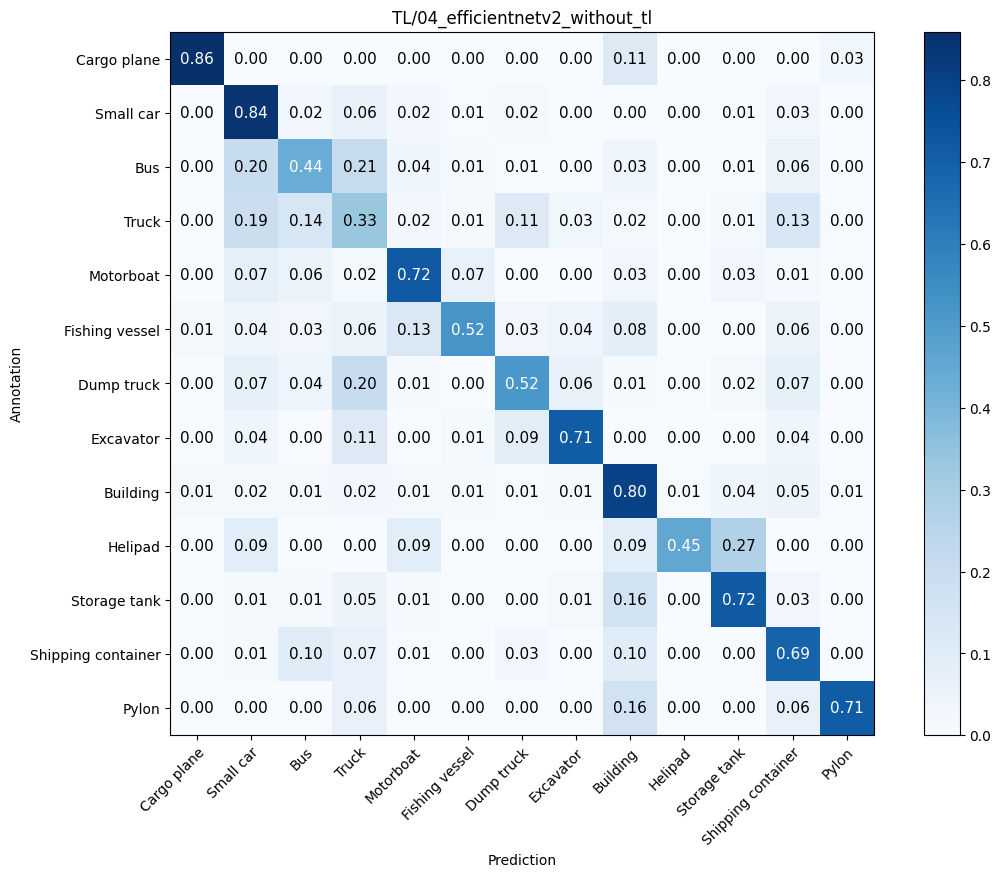

In [14]:
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories, CM_PATH, EXPERIMENT_NAME)

In [15]:
ll = []
# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
global_acc = acc.mean()
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
global_recall = acc.mean()
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
global_precision = acc.mean()
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    ll.append(pd.Series([recall, precision, specificity, f1_score], name=categories[idx], index=["Recall", "Precision", "Specificity", "F1 Score"]))
ll = pd.DataFrame(ll)
sizes_col=pd.Series(y_true).value_counts()
sizes_col.name="Size"
ll = pd.concat([sizes_col, ll, pd.Series([EXPERIMENT_NAME for _ in categories], name='Experiment', index=categories.values())],axis=1)
ll.index.name='Category'
ll = ll.reset_index().set_index(['Experiment','Category'])
ll['Accuracy'] = np.nan
ll.loc[(EXPERIMENT_NAME, 'Global'), ['Size', 'Recall', 'Precision', 'Accuracy']] = [ll.Size.sum().astype(int), global_recall, global_precision, global_acc]
ll = ll.sort_values('Size', ascending=False)
ll.to_csv(METRICS_PATH)
ll.transpose()

Mean Accuracy: 66.293%
Mean Recall: 63.895%
Mean Precision: 67.760%


Experiment  TL/04_efficientnetv2_without_tl                          \
Category                             Global    Building   Small car   
Size                            1875.000000  359.000000  332.000000   
Recall                             0.677598    0.799443    0.840361   
Precision                          0.677598    0.797222    0.711735   
Specificity                             NaN    0.951847    0.926766   
F1 Score                                NaN    0.798331    0.770718   
Accuracy                           0.638951         NaN         NaN   

Experiment                                                           \
Category          Truck         Bus Shipping container Storage tank   
Size         221.000000  177.000000         152.000000   147.000000   
Recall         0.330317    0.435028           0.690789     0.721088   
Precision      0.372449    0.520270           0.544041     0.796992   
Specificity    0.925635    0.958186           0.948926     0.984375   
F1 Score       0.350120    0.473846           0.608696     0.757143   
Accuracy            NaN         NaN                NaN          NaN   

Experiment                                                                 \
Category     Dump truck   Motorboat  Excavator Fishing vessel Cargo plane   
Size         124.000000  107.000000  79.000000      71.000000   64.000000   
Recall         0.516129    0.719626   0.708861       0.521127    0.859375   
Precision      0.587156    0.675439   0.700000       0.672727    0.901639   
Specificity    0.974300    0.979072   0.986637       0.990022    0.996687   
F1 Score       0.549356    0.696833   0.704403       0.587302    0.880000   
Accuracy            NaN         NaN        NaN            NaN         NaN   

Experiment                         
Category         Pylon    Helipad  
Size         31.000000  11.000000  
Recall        0.709677   0.454545  
Precision     0.814815   0.714286  
Specificity   0.997289   0.998927  
F1 Score      0.758621   0.555556  
Accuracy           NaN        NaN

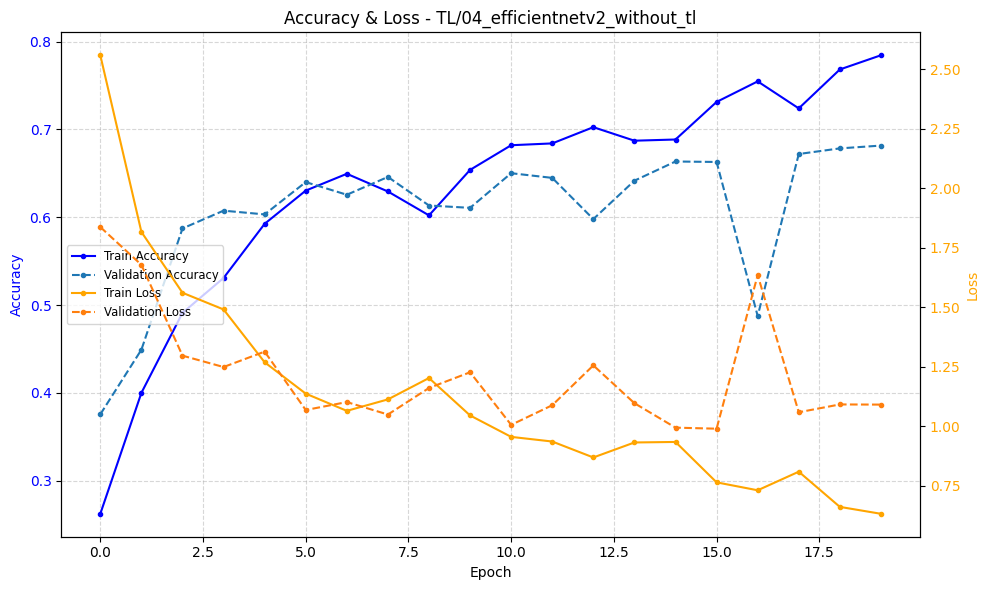

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 6))

plt.title(f'Accuracy & Loss - {EXPERIMENT_NAME}')
ax1.set_xlabel('Epoch')

color_acc = 'blue'
ax1.set_ylabel('Accuracy', color=color_acc)
ax1.plot(h.history['accuracy'], label='Train Accuracy', color='blue', marker='.')
ax1.plot(h.history['val_accuracy'], label='Validation Accuracy', color='tab:blue', linestyle='--', marker='.')
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color_loss = 'orange'
ax2.set_ylabel('Loss', color=color_loss)
ax2.plot(h.history['loss'], label='Train Loss', color='orange', marker='.')
ax2.plot(h.history['val_loss'], label='Validation Loss', color='tab:orange', linestyle='--', marker='.')
ax2.tick_params(axis='y', labelcolor=color_loss)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', frameon=True, fontsize='small')

fig.tight_layout()

plt.savefig(ACC_LOSS_PATH, bbox_inches='tight', dpi=300)

plt.show()

# Testing
Try to improve the results provided in the competition.

In [17]:
anns = []
for (dirpath, dirnames, filenames) in os.walk(os.path.join(XVIEW_RECOGNITION_PATH, 'xview_test')):
    for filename in filenames:
        image = GenericImage(os.path.join(dirpath,filename))
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [18]:
model = tf.keras.models.load_model(MODEL_PATH)
predictions_data = {"images": {}, "annotations": {}}
for idx, ann in enumerate(anns):
    image_data = {"image_id": ann.filename.split('/')[-1], "filename": ann.filename, "width": int(ann.tile[2]), "height": int(ann.tile[3])}
    predictions_data["images"][idx] = image_data
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        annotation_data = {"image_id": ann.filename.split('/')[-1], "category_id": pred_category, "bbox": [int(x) for x in obj_pred.bb]}
        predictions_data["annotations"][idx] = annotation_data

W0000 00:00:1767971013.102868  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767971013.102912  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767971013.102932  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767971013.102963  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767971013.103000  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767971013.103032  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767971013.103069  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767971013.103105  325173 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1767971013.103150  325173 gp

In [19]:
with open(TEST_PREDICTS_PATH, "w") as outfile:
    json.dump(predictions_data, outfile)